<a href="https://colab.research.google.com/github/sujithkumarmp/cloud-ai-basics/blob/main/hf_audio_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
audio_path = "sample_data/audio.mp3"

In [3]:
y,sr = librosa.load(audio_path,sr=None)

In [5]:
y.shape

(51311,)

In [6]:
sr

44100

In [7]:
y

array([ 0.        ,  0.        ,  0.        , ..., -0.17111477,
       -0.207647  , -0.16123243], dtype=float32)

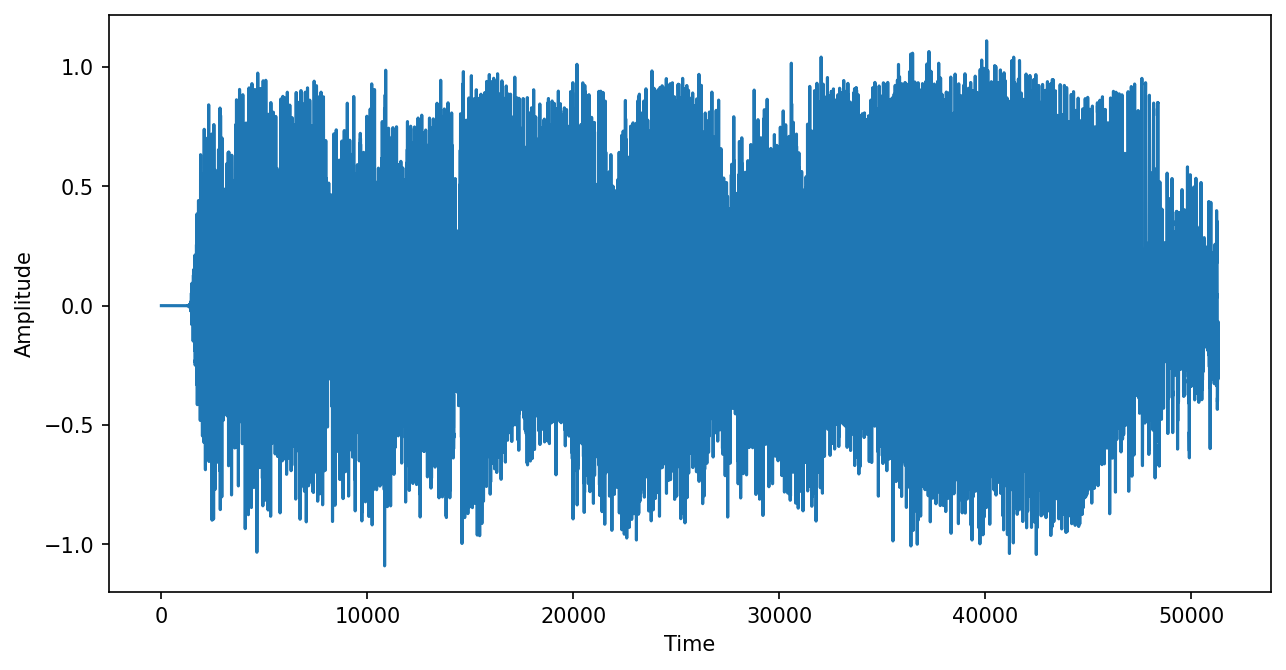

In [12]:
plt.figure(figsize=(10,5),dpi=150)
plt.plot(y)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [13]:
from IPython.display import Audio
Audio(y,rate=sr)

In [14]:
window = np.hanning(len(y))
window_input = y*window
dft = np.fft.rfft(window_input)


In [18]:
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude,ref=np.max)
frequency = librosa.fft_frequencies(sr=sr,n_fft=len(y))

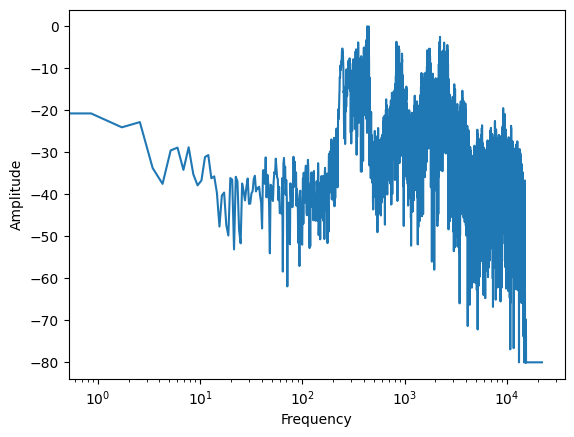

In [20]:
plt.plot(frequency,amplitude_db)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.xscale("log")
plt.show()
#

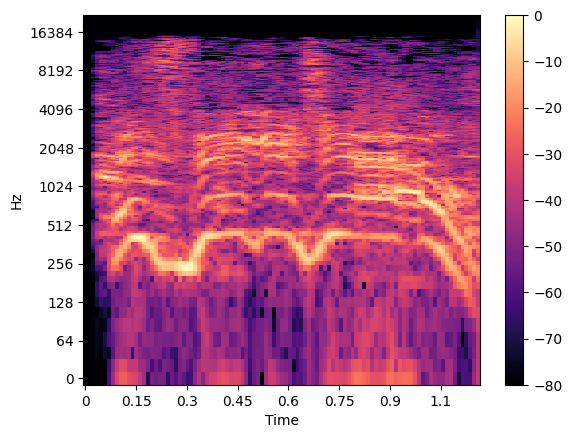

In [21]:
D= librosa.stft(y)
D_db = librosa.amplitude_to_db(np.abs(D),ref=np.max)
librosa.display.specshow(D_db,sr=sr,x_axis='time',y_axis='log')
plt.colorbar()
plt.show()